# PYTHON SQL

## APARTADO A

###  Realiza los mismos ejercicios que en el Apartado B de la práctica la PR_04.2_SQL, pero en esta ocasión utilizando un programa en Python.

#### Conexion

In [1]:
import mysql.connector


try:
    connection = mysql.connector.connect(
        host='empleados.co3yvmofedu9.us-east-1.rds.amazonaws.com',
        port=3306,
        user='admin',
        password = 'AdminContra1'
    ) 
    print('conexion exitosa')
except mysql.connector.Error as e:
    print(e)

conexion exitosa


#### Crea en tu servidor MySQL una base de datos llamada empleados.

In [3]:
delete_query = 'DROP DATABASE IF EXISTS empleados'
create_query = 'CREATE DATABASE empleados'
use_query = 'USE empleados'
try:
    with connection.cursor() as cursor:
        cursor.execute(delete_query)
        cursor.execute(create_query)
        cursor.execute(use_query)
        connection.commit()
        print('Base de datos creada')
except mysql.connector.Error as e:
    print(e)


Base de datos creada


#### Dentro de la base de datos anterior crea las tablas con los campos que se ven abajo y relaciones adecuadas entre las tablas:

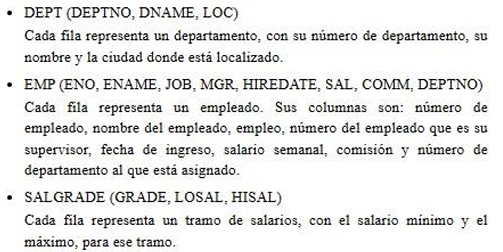

In [4]:


dept_query = """
CREATE TABLE DEPT(
DEPTNO INT PRIMARY KEY,
DNAME VARCHAR(100),
LOC VARCHAR(100)
);
"""
emp_query = """
CREATE TABLE EMP(
ENO INT PRIMARY KEY,
ENAME VARCHAR(100),
JOB VARCHAR(100),
MGR INT,
HIREDATE VARCHAR(100),
SAL INT,
COMM INT,
DEPTNO INT,
FOREIGN KEY (DEPTNO) REFERENCES DEPT(DEPTNO));
"""

sal_query = """
CREATE TABLE SALGRADE(
GRADE INT PRIMARY KEY,
LOSAL INT,
HISAL INT);"""
try:
    with connection.cursor() as cursor:
        cursor.execute(dept_query)
        cursor.execute(emp_query)
        cursor.execute(sal_query)
        connection.commit()
        print('Tablas creadas')
except mysql.connector.Error as e:
    print(e)


Tablas creadas


#### Con las sentencias SQL adecuadas añade a cada tabla los registros siguientes: 

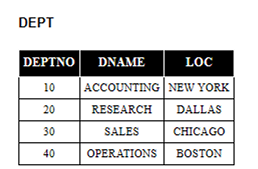

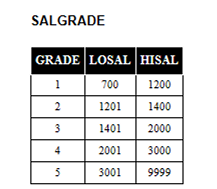

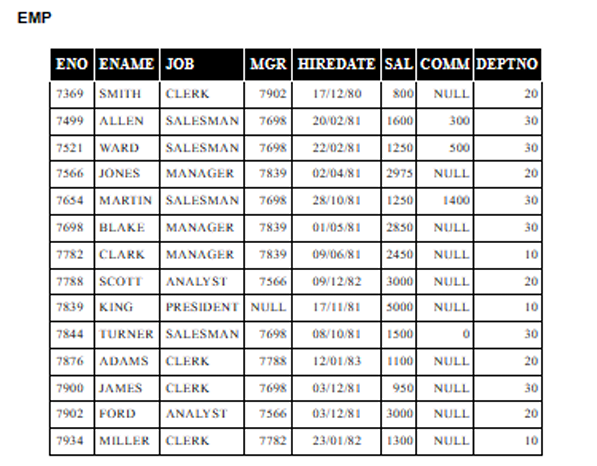

In [5]:
insert_dept_query = '''INSERT INTO DEPT VALUES
(10, 'ACCOUNTING', 'NEW YORK'),
(20, 'RESEARCH', 'DALAS'),
(30, 'SALES', 'CHICAGO'),
(40,'OPERATIONS','BOSTON');'''

insert_emp_query = '''
INSERT INTO EMP VALUES
(7369, 'SMITH', 'CLERK', 7902, '17/12/80', 800, NULL, 20 ),
(7449, 'ALLEN', 'SALESMAN', 7698, '20/02/81', 1600, 300, 30 ),
(7521, 'WARD', 'SALESMAN', 7698, '20/02/81', 1250, 500, 30 ),
(7566, 'JONES', 'MANAGER', 7839, '02/04/81', 2975, NULL, 20 ),
(7654, 'MARTIN', 'SALESMAN', 7698, '28/10/81', 1250, 1400, 30 ),
(7698, 'BLAKE', 'MANAGER', 7839, '01/05/81', 2850, NULL, 30 ),
(7782, 'CLARK', 'MANAGER', 7839, '09/06/81', 2450, NULL, 10 ),
(7788, 'SCOTT', 'ANALYST', 7566, '09/12/82', 3000, NULL, 20 ),
(7839, 'KING', 'PRESIDENT', NULL, '17/11/81', 5000, NULL, 10 ),
(7844, 'TURNER', 'SALESMAN', 7698, '08/10/81', 1500, 0, 30 ),
(7876, 'ADAMS', 'CLERK', 7788, '12/01/83', 1100, NULL, 20 ),
(7900, 'JAMES', 'CLERK', 7698, '03/12/81', 950, NULL, 30 ),
(7902, 'FORD', 'ANALYST', 7566, '03/12/81', 3000, NULL, 20 ),
(7934, 'MILLER', 'CLERK', 7782, '23/01/82', 1300, NULL, 10 );'''

insert_salgrade_query = '''
INSERT INTO SALGRADE VALUES
(1,700,1200),
(2,1201,1400),
(3,1401,2000),
(4,2001,3000),
(5,3001,9999);'''
try:
    with connection.cursor() as cursor:
        cursor.execute(insert_dept_query)
        cursor.execute(insert_emp_query)
        cursor.execute(insert_salgrade_query)
        connection.commit()
        print('Valores insertados')
except mysql.connector.Error as e:
    print(e)

Valores insertados


### Realiza las siguientes consultas mostrando también su salida por pantalla.

#### Seleccionar el nº de empleado, salario, comisión, nº de departamento <br> y fecha de la tabla EMP. 

In [8]:
select_emp_query = 'SELECT ENO,SAL,COMM,DEPTNO,HIREDATE FROM EMP;'

with connection.cursor() as cursor:
    cursor.execute(select_emp_query)
    for row in cursor.fetchall():
        print(row)
    

(7369, 800, None, 20, '17/12/80')
(7449, 1600, 300, 30, '20/02/81')
(7521, 1250, 500, 30, '20/02/81')
(7566, 2975, None, 20, '02/04/81')
(7654, 1250, 1400, 30, '28/10/81')
(7698, 2850, None, 30, '01/05/81')
(7782, 2450, None, 10, '09/06/81')
(7788, 3000, None, 20, '09/12/82')
(7839, 5000, None, 10, '17/11/81')
(7844, 1500, 0, 30, '08/10/81')
(7876, 1100, None, 20, '12/01/83')
(7900, 950, None, 30, '03/12/81')
(7902, 3000, None, 20, '03/12/81')
(7934, 1300, None, 10, '23/01/82')


#### Seleccionar todas las columnas de la tabla DEPT.

In [9]:
select_dept_query = 'SELECT * FROM DEPT;'

with connection.cursor() as cursor:
    cursor.execute(select_dept_query)
    for row in cursor.fetchall():
        print(row)

(10, 'ACCOUNTING', 'NEW YORK')
(20, 'RESEARCH', 'DALAS')
(30, 'SALES', 'CHICAGO')
(40, 'OPERATIONS', 'BOSTON')


#### Seleccionar los nombres y los empleos de todos los empleados, ordenados por empleo 


In [10]:
select_ne_query = 'SELECT ENAME,JOB FROM EMP ORDER BY JOB'

with connection.cursor() as cursor:
    cursor.execute(select_ne_query)
    for row in cursor.fetchall():
        print(row)

('SCOTT', 'ANALYST')
('FORD', 'ANALYST')
('SMITH', 'CLERK')
('ADAMS', 'CLERK')
('JAMES', 'CLERK')
('MILLER', 'CLERK')
('JONES', 'MANAGER')
('BLAKE', 'MANAGER')
('CLARK', 'MANAGER')
('KING', 'PRESIDENT')
('ALLEN', 'SALESMAN')
('WARD', 'SALESMAN')
('MARTIN', 'SALESMAN')
('TURNER', 'SALESMAN')


#### Seleccionar los empleos que hay en cada departamento, ordenados por departamento 

In [11]:
select_ed_query = 'SELECT DEPT.DNAME, EMP.JOB FROM DEPT JOIN EMP ON DEPT.DEPTNO = EMP.DEPTNO ORDER BY DEPT.DNAME'
with connection.cursor() as cursor:
    cursor.execute(select_ed_query)
    for row in cursor.fetchall():
        print(row)

('ACCOUNTING', 'MANAGER')
('ACCOUNTING', 'PRESIDENT')
('ACCOUNTING', 'CLERK')
('RESEARCH', 'CLERK')
('RESEARCH', 'MANAGER')
('RESEARCH', 'ANALYST')
('RESEARCH', 'CLERK')
('RESEARCH', 'ANALYST')
('SALES', 'SALESMAN')
('SALES', 'SALESMAN')
('SALES', 'SALESMAN')
('SALES', 'MANAGER')
('SALES', 'SALESMAN')
('SALES', 'CLERK')


#### Seleccionar los distintos departamentos que existen en la tabla EMP. 

In [13]:
select_d_query= 'SELECT DISTINCT EMP.DEPTNO, DEPT.DNAME FROM DEPT JOIN EMP ON DEPT.DEPTNO = EMP.DEPTNO'
with connection.cursor() as cursor:
    cursor.execute(select_d_query)
    for row in cursor.fetchall():
        print(row)

(10, 'ACCOUNTING')
(20, 'RESEARCH')
(30, 'SALES')


#### Calcular el salario anual a percibir por cada empleado.

In [20]:
select_sal_query = 'SELECT ENO, SAL*12 FROM EMP'
with connection.cursor() as cursor:
    cursor.execute(select_sal_query)
    for row in cursor.fetchall():
        print(row)


(7369, 9600)
(7449, 19200)
(7521, 15000)
(7566, 35700)
(7654, 15000)
(7698, 34200)
(7782, 29400)
(7788, 36000)
(7839, 60000)
(7844, 18000)
(7876, 13200)
(7900, 11400)
(7902, 36000)
(7934, 15600)


####  Mostrar el nombre del empleado y una columna que contenga el salario multiplicado por la comisión cuya cabecera sea “BONO” 


In [21]:
select_bon_query = 'SELECT ENAME, SAL*COMM AS BONO FROM EMP'
with connection.cursor() as cursor:
    cursor.execute(select_bon_query)
    print(cursor.column_names)
    for row in cursor.fetchall():
        print(row)


('ENAME', 'BONO')
('SMITH', None)
('ALLEN', 480000)
('WARD', 625000)
('JONES', None)
('MARTIN', 1750000)
('BLAKE', None)
('CLARK', None)
('SCOTT', None)
('KING', None)
('TURNER', 0)
('ADAMS', None)
('JAMES', None)
('FORD', None)
('MILLER', None)


#### Seleccionar aquellos empleados que sean "SALESMAN”. 

In [22]:
select_sales_query = 'SELECT ENO FROM EMP WHERE JOB = "SALESMAN"'
with connection.cursor() as cursor:
    cursor.execute(select_sales_query)
    for row in cursor.fetchall():
        print(row)

(7449,)
(7521,)
(7654,)
(7844,)


#### Seleccionar aquellos empleados que no trabajen en el departamento 30

In [23]:
select_np_query = 'SELECT ENO FROM EMP WHERE DEPTNO != 30'
with connection.cursor() as cursor:
    cursor.execute(select_np_query)
    for row in cursor.fetchall():
        print(row)

(7782,)
(7839,)
(7934,)
(7369,)
(7566,)
(7788,)
(7876,)
(7902,)


#### Seleccionar el nombre de aquellos empleados que ganen más de 2000. 

In [25]:
select_mdmil_query = 'SELECT ENAME FROM EMP WHERE SAL > 2000'
with connection.cursor() as cursor:
    cursor.execute(select_mdmil_query)
    for row in cursor.fetchall():
        print(row)

('JONES',)
('BLAKE',)
('CLARK',)
('SCOTT',)
('KING',)
('FORD',)


#### Seleccionar aquellos empleados que hayan entrado antes del 1/1/82

In [32]:
select_date_query = 'SELECT ENO FROM EMP WHERE STR_TO_DATE(HIREDATE,"%d/%m/%y") < STR_TO_DATE("01/01/82","%d/%m/%y")'
with connection.cursor() as cursor:
    cursor.execute(select_date_query)
    for row in cursor.fetchall():
        print(row)

(7369,)
(7449,)
(7521,)
(7566,)
(7654,)
(7698,)
(7782,)
(7839,)
(7844,)
(7900,)
(7902,)


#### Mostrar el nombre del empleado y su fecha de alta en la empresa de los empleados que son “ANALISTA”. 

In [33]:
select_an_query = 'SELECT ENAME,HIREDATE FROM EMP WHERE JOB = "ANALYST"'
with connection.cursor() as cursor:
    cursor.execute(select_an_query)
    for row in cursor.fetchall():
        print(row)

('SCOTT', '09/12/82')
('FORD', '03/12/81')


#### Seleccionar los empleados cuyo salario sea superior al de “ADAMS”. 

In [8]:
select_ad_query = 'SELECT ENO FROM EMP WHERE SAL > (SELECT SAL FROM EMP WHERE ENAME = "ADAMS")'
with connection.cursor() as cursor:
    cursor.execute(select_ad_query)
    for row in cursor.fetchall():
        print(row)

(7449,)
(7521,)
(7566,)
(7654,)
(7698,)
(7782,)
(7788,)
(7839,)
(7844,)
(7902,)
(7934,)


#### Seleccionar los empleados que trabajan en el mismo departamento que "CLARK”. 

In [9]:
select_cl_query = 'SELECT ENO FROM EMP WHERE DEPTNO = (SELECT DEPTNO FROM EMP WHERE ENAME = "CLARK")'
with connection.cursor() as cursor:
    cursor.execute(select_cl_query)
    for row in cursor.fetchall():
        print(row)

(7782,)
(7839,)
(7934,)


#### Encontrar a los empleados cuyo jefe es “BLAKE”.

In [10]:
select_bl_query = 'SELECT ENO FROM EMP WHERE MGR = (SELECT ENO FROM EMP WHERE ENAME = "BLAKE")'
with connection.cursor() as cursor:
    cursor.execute(select_bl_query)
    for row in cursor.fetchall():
        print(row)

(7449,)
(7521,)
(7654,)
(7844,)
(7900,)


#### Seleccionar el nombre de los vendedores que ganen más de 1500. 

In [12]:
select_sl_query = 'SELECT ENAME FROM EMP WHERE SAL > 1500 AND JOB = "SALESMAN"'
with connection.cursor() as cursor:
    cursor.execute(select_sl_query)
    for row in cursor.fetchall():
        print(row)

('ALLEN',)


#### Seleccionar aquellos empleados que tienen comisión. 

In [13]:
select_cm_query = 'SELECT ENO FROM EMP WHERE COMM IS NOT NULL'
with connection.cursor() as cursor:
    cursor.execute(select_cm_query)
    for row in cursor.fetchall():
        print(row)

(7449,)
(7521,)
(7654,)
(7844,)


#### Seleccionar aquellos que se llamen “SMITH”, "ALLEN” o “SCOTT “. 

In [14]:
select_nm_query = 'SELECT ENO FROM EMP WHERE ENAME IN ("SMITH","ALLEN","SCOTT")'
with connection.cursor() as cursor:
    cursor.execute(select_nm_query)
    for row in cursor.fetchall():
        print(row)

(7369,)
(7449,)
(7788,)


### Seleccionar aquellos que no se llamen "SMITH", “ALLEN” o “SCOTT “. 

In [15]:
select_nnm_query = 'SELECT ENO FROM EMP WHERE ENAME NOT IN ("SMITH","ALLEN","SCOTT")'
with connection.cursor() as cursor:
    cursor.execute(select_nnm_query)
    for row in cursor.fetchall():
        print(row)

(7521,)
(7566,)
(7654,)
(7698,)
(7782,)
(7839,)
(7844,)
(7876,)
(7900,)
(7902,)
(7934,)


#### Seleccionar los empleados que trabajen en "CHICAGO". 

In [16]:
select_ch_query = 'SELECT EMP.ENO FROM EMP JOIN DEPT ON EMP.DEPTNO = DEPT.DEPTNO WHERE DEPT.LOC = "CHICAGO"'
with connection.cursor() as cursor:
    cursor.execute(select_ch_query)
    for row in cursor.fetchall():
        print(row)

(7449,)
(7521,)
(7654,)
(7698,)
(7844,)
(7900,)


#### Seleccionar aquellos empleados que trabajen en el departamento 10 o en el 20. 

In [17]:
select_dpt_query = 'SELECT ENO FROM EMP WHERE DEPTNO IN (10,20)'
with connection.cursor() as cursor:
    cursor.execute(select_dpt_query)
    for row in cursor.fetchall():
        print(row)

(7782,)
(7839,)
(7934,)
(7369,)
(7566,)
(7788,)
(7876,)
(7902,)


#### Cerramos la conexión

In [18]:
try:
    connection.close()
    print('Conexión cerrada')
except mysql.connector.Error as e:
    print(e)



Conexión cerrada
